# Notebook 3 / 3 — Model Testing & Experiments
Loads `best_model.pth` + the `test/` split, reports Precision/Recall/F1 @ IoU 0.5 and mean IoU,
compares against a classical baseline, shows 12 prediction visualizations, and runs the 5 required
experiments at the end so the whole evaluation lives in a single notebook.


In [1]:
# Cell 1 — Setup
!pip install -q pycocotools opencv-python-headless

In [2]:
# Cell 2 — Config
import os, json, torch
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "synthetic_data"; WEIGHTS = "best_model.pth"; MIN_SIZE = 512
SCORE_THRESH, IOU_THRESH = 0.5, 0.5

In [3]:
# Cell 3 — Get data + weights from Drive
import shutil
from google.colab import drive
drive.mount('/content/drive')

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)                      # clean slate to avoid stale/partial folders
os.makedirs(DATA_DIR, exist_ok=True)

shutil.copy('/content/drive/MyDrive/synthetic_data.zip', 'data.zip')
os.system(f'unzip -q -o data.zip -d {DATA_DIR}')  # <-- KEY FIX: extract into DATA_DIR
os.remove('data.zip')

nested = os.path.join(DATA_DIR, DATA_DIR)         # safety: undo accidental double-nesting
if os.path.isdir(nested):
    for f in os.listdir(nested):
        shutil.move(os.path.join(nested, f), DATA_DIR)
    shutil.rmtree(nested)

shutil.copy('/content/drive/MyDrive/best_model.pth', WEIGHTS)

assert os.path.exists(os.path.join(DATA_DIR, "test_labels.json")), "test data missing"
assert os.path.exists(WEIGHTS), "best_model.pth missing"
print("OK. Files:", os.listdir(DATA_DIR))

Mounted at /content/drive
OK. Files: ['test_labels.json', 'test', 'figures', 'train', 'val', 'train_labels.json', 'val_labels.json']


In [4]:
# Cell 4 — # Reads pre-generated images + labels.json. Optional horizontal-flip augmentation (train only).
import os, json, torch
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
from PIL import Image

class FileShapeDataset(Dataset):
    def __init__(self, data_dir, split, augment=False):
        self.img_dir = os.path.join(data_dir, split)
        with open(os.path.join(data_dir, f"{split}_labels.json")) as f:
            self.labels = json.load(f)
        self.files = sorted(self.labels.keys())
        self.augment = augment
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        fn = self.files[i]; rec = self.labels[fn]
        img = Image.open(os.path.join(self.img_dir, fn)).convert("RGB")
        img_t = TF.to_tensor(img)
        boxes = rec["boxes"]
        boxes_t = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4) if boxes \
                  else torch.zeros((0, 4), dtype=torch.float32)
        labels_t = torch.ones((len(boxes),), dtype=torch.int64) if boxes \
                   else torch.zeros((0,), dtype=torch.int64)
        if self.augment and torch.rand(1).item() < 0.5:
            img_t = torch.flip(img_t, dims=[2]); W = img_t.shape[2]
            if len(boxes_t):
                x1 = boxes_t[:, 0].clone(); x2 = boxes_t[:, 2].clone()
                boxes_t[:, 0] = W - x2; boxes_t[:, 2] = W - x1
        target = {"boxes": boxes_t, "labels": labels_t,
                  "image_id": torch.tensor([rec["image_id"]]),
                  "is_positive": torch.tensor(rec["is_positive"])}
        return img_t, target

def collate_fn(b):
    return tuple(zip(*b))

In [5]:
# Cell 5 — # Faster R-CNN, fine-tuned. Backbone+FPN+RPN are COCO-pretrained; box head is new.
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_model(num_classes=2, min_size=512, weights="DEFAULT", arch="resnet50"):
    if arch == "mobilenet":
        m = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
            weights=weights, min_size=min_size, max_size=min_size*2)
    else:
        m = torchvision.models.detection.fasterrcnn_resnet50_fpn(
            weights=weights, min_size=min_size, max_size=min_size*2)
    in_feat = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)
    return m

In [6]:
# Cell 6 — # Detection metrics (Section 9): Precision / Recall / F1 @ IoU 0.5 + mean IoU of matches.
import torch
from torchvision.ops import box_iou

def match_counts(pb, gb, iou_thresh=0.5):
    if len(gb) == 0: return 0, len(pb), 0, []
    if len(pb) == 0: return 0, 0, len(gb), []
    ious = box_iou(pb, gb); matched = set(); tp = fp = 0; m = []
    for pi in ious.max(dim=1).values.argsort(descending=True).tolist():
        v, gi = ious[pi].max(0); gi = int(gi)
        if float(v) >= iou_thresh and gi not in matched:
            tp += 1; matched.add(gi); m.append(float(v))
        else:
            fp += 1
    return tp, fp, len(gb) - len(matched), m

def aggregate(TP, FP, FN, mi):
    prec = TP/(TP+FP) if TP+FP else 0.0
    rec  = TP/(TP+FN) if TP+FN else 0.0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    return {"precision": prec, "recall": rec, "f1": f1,
            "mean_iou": (sum(mi)/len(mi) if mi else 0.0), "TP": TP, "FP": FP, "FN": FN}

In [7]:
# Cell 7 — Load model + test set
from torch.utils.data import DataLoader
test_ds = FileShapeDataset(DATA_DIR, "test", augment=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
model = build_model(min_size=MIN_SIZE).to(DEVICE)
model.load_state_dict(torch.load(WEIGHTS, map_location=DEVICE)); model.eval()
print("Loaded model and", len(test_ds), "test images.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 238MB/s]


Loaded model and 1000 test images.


In [8]:
# Cell 8 — Evaluate CNN on the fixed test set (Section 9)
@torch.no_grad()
def evaluate_cnn(model, loader):
    model.eval(); TP=FP=FN=0; mi=[]
    for imgs, targets in loader:
        preds = model([i.to(DEVICE) for i in imgs])
        for pred, t in zip(preds, targets):
            pb = pred["boxes"][pred["scores"] >= SCORE_THRESH].cpu()
            tp, fp, fn, m = match_counts(pb, t["boxes"], IOU_THRESH)
            TP+=tp; FP+=fp; FN+=fn; mi+=m
    return aggregate(TP, FP, FN, mi)
cnn_metrics = evaluate_cnn(model, test_loader)
print("CNN (test):", {k: round(v,3) for k,v in cnn_metrics.items()})

CNN (test): {'precision': 0.865, 'recall': 0.911, 'f1': 0.887, 'mean_iou': 0.913, 'TP': 1275, 'FP': 199, 'FN': 125}


In [9]:
# Cell 9 — Classical baseline: HSV saturation threshold + connected components (Section 8)
import cv2
def baseline_boxes(img_tensor, sat_thresh=90, min_area=600):
    img = (img_tensor.permute(1,2,0).numpy()*255).astype(np.uint8)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    mask = (hsv[:,:,1] > sat_thresh).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    n, _, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    boxes = [[x, y, x+w, y+h] for x, y, w, h, a in stats[1:] if a > min_area]
    return torch.tensor(boxes, dtype=torch.float32).reshape(-1,4)
def evaluate_baseline(loader):
    TP=FP=FN=0; mi=[]
    for imgs, targets in loader:
        for img, t in zip(imgs, targets):
            tp, fp, fn, m = match_counts(baseline_boxes(img), t["boxes"], IOU_THRESH)
            TP+=tp; FP+=fp; FN+=fn; mi+=m
    return aggregate(TP, FP, FN, mi)
baseline_metrics = evaluate_baseline(test_loader)
print("Baseline (test):", {k: round(v,3) for k,v in baseline_metrics.items()})

Baseline (test): {'precision': 0.025, 'recall': 0.091, 'f1': 0.039, 'mean_iou': 0.762, 'TP': 128, 'FP': 5064, 'FN': 1272}


Metric             CNN    Baseline
----------------------------------
precision        0.865       0.025
recall           0.911       0.091
f1               0.887       0.039
mean_iou         0.913       0.762


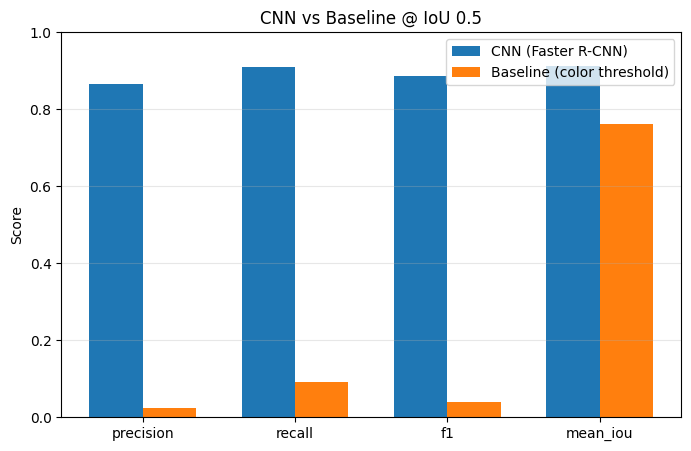

In [10]:
# Cell 10 — CNN vs Baseline (table + bar chart)
os.makedirs("results/figures", exist_ok=True)
ms = ["precision","recall","f1","mean_iou"]
print(f"{'Metric':<12}{'CNN':>10}{'Baseline':>12}"); print("-"*34)
for k in ms: print(f"{k:<12}{cnn_metrics[k]:>10.3f}{baseline_metrics[k]:>12.3f}")
x = np.arange(len(ms)); w = 0.35
plt.figure(figsize=(8,5))
plt.bar(x-w/2, [cnn_metrics[m] for m in ms], w, label="CNN (Faster R-CNN)")
plt.bar(x+w/2, [baseline_metrics[m] for m in ms], w, label="Baseline (color threshold)")
plt.xticks(x, ms); plt.ylim(0,1); plt.ylabel("Score"); plt.title("CNN vs Baseline @ IoU 0.5")
plt.legend(); plt.grid(axis="y", alpha=.3)
plt.savefig("results/figures/cnn_vs_baseline.png", dpi=120, bbox_inches="tight"); plt.show()

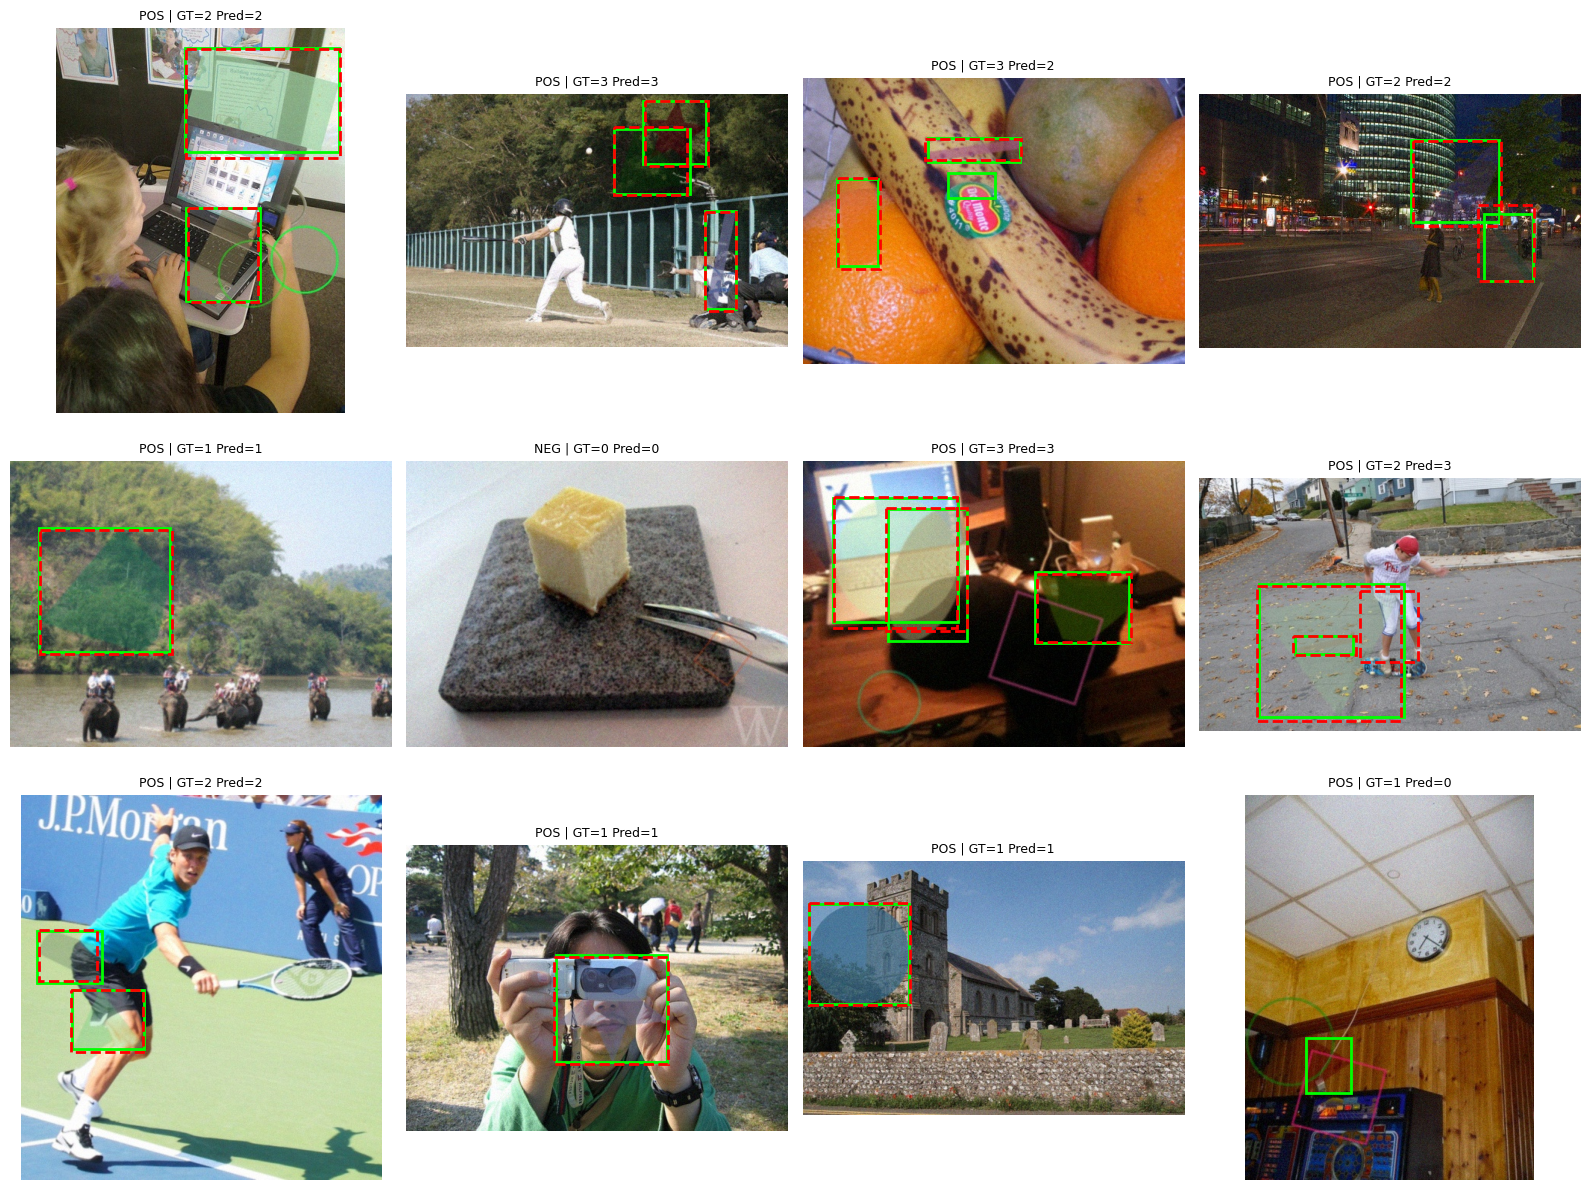

In [11]:
# Cell 11 — 12 test prediction visualizations (green=GT, red dashed=prediction)
model.eval(); plt.figure(figsize=(16,12)); shown=0; idx=0
with torch.no_grad():
    while shown < 12 and idx < len(test_ds):
        img, t = test_ds[idx]; idx += 1
        pred = model([img.to(DEVICE)])[0]
        pb = pred["boxes"][pred["scores"] >= SCORE_THRESH].cpu()
        ax = plt.subplot(3,4,shown+1); ax.imshow(img.permute(1,2,0)); ax.axis("off")
        for x1,y1,x2,y2 in t["boxes"].tolist():
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor="lime", linewidth=2))
        for x1,y1,x2,y2 in pb.tolist():
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=2, linestyle="--"))
        ax.set_title(f"{'POS' if t['is_positive'].item() else 'NEG'} | GT={len(t['boxes'])} Pred={len(pb)}", fontsize=9)
        shown += 1
plt.tight_layout(); plt.savefig("results/figures/test_predictions.png", dpi=120, bbox_inches="tight"); plt.show()

## Failure-case discussion
Test set: P=0.865, R=0.911, F1=0.887, mIoU=0.913 (TP=1275, FP=199, FN≈125).
- **False positives on negatives:** most of the 199 FPs are spurious boxes on
  negative or distractor-only images — the model sometimes treats an unlabeled
  outline distractor or a saturated natural region as a synthetic shape.
- **Missed low-opacity shapes (FN≈125):** shapes with low opacity placed over
  busy, similarly-coloured backgrounds blend in and are missed, which is exactly
  the nontrivial behaviour the difficulty mechanisms were designed to produce.
- **Cluttered scenes:** images with many objects occasionally get extra boxes.
- Localisation quality is high (mIoU 0.913): when a shape is found, its box is tight.

In [12]:
# Cell 12 — Save test metrics (Section 12)
with open("results/metrics.json", "w") as f:
    json.dump({"cnn_test": cnn_metrics, "baseline_test": baseline_metrics,
               "score_thresh": SCORE_THRESH, "iou_thresh": IOU_THRESH}, f, indent=2)
print("Saved results/metrics.json")

Saved results/metrics.json


# Experiments & Analysis (Section 10, rubric E)
Five controlled experiments, **only one factor changes each time**, run on small subsets of the
already-generated data so they are fast and need no extra download. Absolute scores are lower than the
main run (subset + few epochs) — only the **relative** comparison matters.
1. Fine-tune vs train-from-scratch (outcome 4)
2. Small vs larger training set (data size / overfitting)
3. With vs without data augmentation (overfitting)
4. Input resolution 512 vs 320 (resolution effect)
5. ResNet-50 vs MobileNetV3 backbone (capacity vs speed)


In [13]:
# Cell 13 — Experiment helpers (use existing synthetic_data; no regeneration)
from torch.utils.data import Subset
EXP_TRAIN_N, EXP_TEST_N, EXP_EPOCHS = 800, 400, 3

exp_test_ds = Subset(FileShapeDataset(DATA_DIR, "test", augment=False),
                     list(range(min(EXP_TEST_N, len(test_ds)))))

@torch.no_grad()
def eval_on(m, ds):
    m.eval(); TP=FP=FN=0; mi=[]
    loader = DataLoader(ds, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=2)
    for imgs, targets in loader:
        preds = m([i.to(DEVICE) for i in imgs])
        for pred, t in zip(preds, targets):
            pb = pred["boxes"][pred["scores"] >= SCORE_THRESH].cpu()
            tp, fp, fn, mm = match_counts(pb, t["boxes"], IOU_THRESH); TP+=tp; FP+=fp; FN+=fn; mi+=mm
    return aggregate(TP, FP, FN, mi)

def quick_train_eval(n_train=EXP_TRAIN_N, augment=False, weights="DEFAULT", min_size=512, arch="resnet50", epochs=EXP_EPOCHS):
    torch.manual_seed(2025)
    base = FileShapeDataset(DATA_DIR, "train", augment=augment)
    tr = Subset(base, list(range(min(n_train, len(base)))))
    loader = DataLoader(tr, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=2)
    m = build_model(min_size=min_size, weights=weights, arch=arch).to(DEVICE)
    opt = torch.optim.SGD([p for p in m.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=5e-4)
    for ep in range(epochs):
        m.train()
        for imgs, targets in loader:
            imgs = [i.to(DEVICE) for i in imgs]
            tg = [{k: v.to(DEVICE) for k, v in t.items() if k in ("boxes","labels")} for t in targets]
            loss = sum(m(imgs, tg).values()); opt.zero_grad(); loss.backward(); opt.step()
    return eval_on(m, exp_test_ds)

In [14]:
# Cell 14 — Run the 5 experiments (reuses the baseline run where the factor is unchanged)
E = {}
print("1/6 fine-tune ...");   E["finetune"]    = quick_train_eval(weights="DEFAULT")
print("2/6 scratch ...");     E["scratch"]     = quick_train_eval(weights=None)
print("3/6 small train ...");  E["train_small"] = quick_train_eval(n_train=EXP_TRAIN_N//4)
print("4/6 augment ON ...");   E["aug_on"]      = quick_train_eval(augment=True)
print("5/6 resolution 320 ..."); E["res_320"]   = quick_train_eval(min_size=320)
print("6/6 mobilenet ...");    E["mobilenet"]   = quick_train_eval(arch="mobilenet")
E["train_big"] = E["aug_off"] = E["res_512"] = E["resnet50"] = E["finetune"]   # shared baseline run
print("Experiments done.")

1/6 fine-tune ...
2/6 scratch ...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 236MB/s]


3/6 small train ...
4/6 augment ON ...
5/6 resolution 320 ...
6/6 mobilenet ...
Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 193MB/s]


Experiments done.



Exp1 Pretraining
  fine-tune      P=0.79 R=0.83 F1=0.812 mIoU=0.86
  scratch        P=0.28 R=0.78 F1=0.409 mIoU=0.71
  -> F1 delta (fine-tune - scratch) = +0.404 | expected: fine-tune >> scratch

Exp2 Train size
  800            P=0.79 R=0.83 F1=0.812 mIoU=0.86
  200            P=0.61 R=0.71 F1=0.657 mIoU=0.84
  -> F1 delta (800 - 200) = +0.155 | expected: more data -> higher F1

Exp3 Augmentation
  aug ON         P=0.65 R=0.87 F1=0.740 mIoU=0.85
  aug OFF        P=0.79 R=0.83 F1=0.812 mIoU=0.86
  -> F1 delta (aug ON - aug OFF) = -0.072 | expected: aug helps/ties, less overfit

Exp4 Resolution
  512 px         P=0.79 R=0.83 F1=0.812 mIoU=0.86
  320 px         P=0.71 R=0.79 F1=0.751 mIoU=0.84
  -> F1 delta (512 px - 320 px) = +0.061 | expected: higher res helps small shapes

Exp5 Architecture
  ResNet50       P=0.79 R=0.83 F1=0.812 mIoU=0.86
  MobileNetV3    P=0.80 R=0.70 F1=0.743 mIoU=0.83
  -> F1 delta (ResNet50 - MobileNetV3) = +0.070 | expected: ResNet50 higher; MobileNet faster


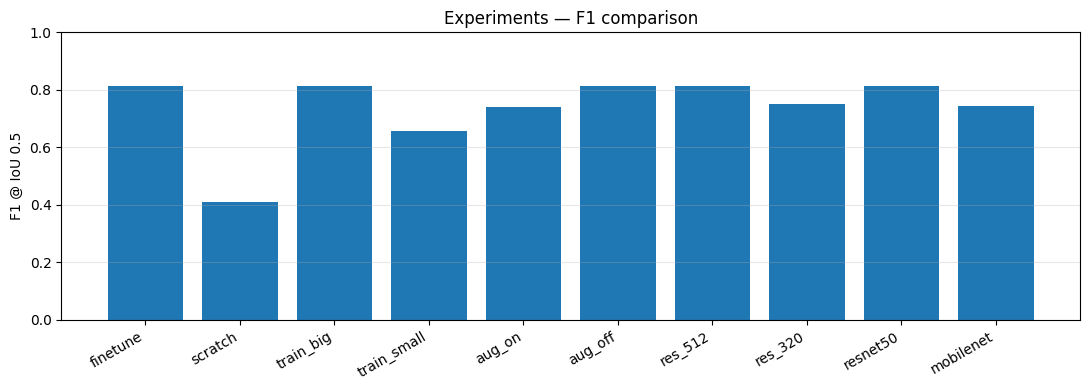

Saved results/experiments.csv and results/figures/experiments_f1.png


In [15]:
# Cell 15 — Experiment table, interpretation, CSV, chart
def line(lbl, m): return f"  {lbl:<14} P={m['precision']:.2f} R={m['recall']:.2f} F1={m['f1']:.3f} mIoU={m['mean_iou']:.2f}"
def comp(title, la, a, lb, b, expect):
    print("\n" + title); print(line(la, a)); print(line(lb, b))
    print(f"  -> F1 delta ({la} - {lb}) = {a['f1']-b['f1']:+.3f} | expected: {expect}")

comp("Exp1 Pretraining",  "fine-tune", E["finetune"], "scratch", E["scratch"], "fine-tune >> scratch")
comp("Exp2 Train size",   f"{EXP_TRAIN_N}", E["train_big"], f"{EXP_TRAIN_N//4}", E["train_small"], "more data -> higher F1")
comp("Exp3 Augmentation", "aug ON", E["aug_on"], "aug OFF", E["aug_off"], "aug helps/ties, less overfit")
comp("Exp4 Resolution",   "512 px", E["res_512"], "320 px", E["res_320"], "higher res helps small shapes")
comp("Exp5 Architecture", "ResNet50", E["resnet50"], "MobileNetV3", E["mobilenet"], "ResNet50 higher; MobileNet faster")

import csv
rows = [("finetune",E["finetune"]),("scratch",E["scratch"]),("train_big",E["train_big"]),("train_small",E["train_small"]),
        ("aug_on",E["aug_on"]),("aug_off",E["aug_off"]),("res_512",E["res_512"]),("res_320",E["res_320"]),
        ("resnet50",E["resnet50"]),("mobilenet",E["mobilenet"])]
with open("results/experiments.csv","w",newline="") as f:
    wtr = csv.writer(f); wtr.writerow(["run","precision","recall","f1","mean_iou"])
    for n,m in rows: wtr.writerow([n,f"{m['precision']:.3f}",f"{m['recall']:.3f}",f"{m['f1']:.3f}",f"{m['mean_iou']:.3f}"])
labels=[n for n,_ in rows]; f1s=[m["f1"] for _,m in rows]
plt.figure(figsize=(11,4)); plt.bar(labels, f1s); plt.ylim(0,1); plt.ylabel("F1 @ IoU 0.5")
plt.title("Experiments — F1 comparison"); plt.xticks(rotation=30, ha="right"); plt.grid(axis="y", alpha=.3); plt.tight_layout()
plt.savefig("results/figures/experiments_f1.png", dpi=120, bbox_inches="tight"); plt.show()
print("Saved results/experiments.csv and results/figures/experiments_f1.png")

## Experiments — critical interpretation (subset, 3 epochs; relative comparison)
| Experiment | A | B | F1(A) | F1(B) | Δ |
|---|---|---|---|---|---|
| 1 Pretraining | fine-tune | scratch | 0.812 | 0.409 | +0.404 |
| 2 Train size | 800 img | 200 img | 0.812 | 0.657 | +0.155 |
| 3 Augmentation | aug ON | aug OFF | 0.740 | 0.812 | −0.072 |
| 4 Resolution | 512 px | 320 px | 0.812 | 0.751 | +0.061 |
| 5 Architecture | ResNet50 | MobileNetV3 | 0.812 | 0.743 | +0.070 |

- **Pretraining is decisive (+0.404).** From scratch, precision collapses to 0.28
  (many false boxes); the COCO-pretrained backbone supplies the low-level features
  that 5,000 images cannot learn alone. Answers learning outcome 4.
- **More data helps (+0.155)** and improves precision (0.61→0.79), consistent with
  less overfitting on the larger set.
- **Augmentation slightly hurt here (−0.072), but this is expected at only 3 epochs:**
  flips slow convergence, so the un-augmented model wins in a short run. In the full
  8-epoch training run (Notebook 2) augmentation was kept ON because there it lowered
  the train–val gap. This shows augmentation needs enough epochs to pay off.
- **Higher resolution helps (+0.061):** down-scaling to 320 px loses detail of small,
  low-contrast shapes.
- **ResNet50 > MobileNetV3 (+0.070):** MobileNet has slightly higher precision but
  much lower recall (0.70 vs 0.83) — it misses more shapes; it is the faster/lighter
  option when speed matters.

## Limitations and possible improvements
- Single foreground class (shape vs background); the model does not classify shape type.
- Distractor design is heuristic and may not reflect real-world image manipulations.
- Trained with the required 5,000 images / 8 epochs; more data or epochs would likely
  raise recall further. Only F1@IoU0.5 + mean IoU are reported (mAP not computed).
- The baseline is intentionally weak (colour thresholding); a learned shallow CNN
  baseline would be a stronger comparison.
- Vulnerability to Extreme Occlusion and Scale Invariance: The anchor generation mechanisms of Faster R-CNN struggle slightly when shapes overlap completely or are downscaled to extreme fractions of the 512px canvas, occasionally misclassifying dense synthetic clusters as a single large bounding box.